In [1]:
# SECTION 1 — Imports & Helpers
import numpy as np
import time
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import real_amplitudes
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize


# ── Amplitude-encode a real vector |v> into a quantum circuit ──
def amplitude_encode(vec):
    """Returns a QuantumCircuit that initialises |vec> (normalised)."""
    v = np.array(vec, dtype=float)
    n = v / (np.linalg.norm(v) + 1e-30)
    n_qubits = int(np.ceil(np.log2(len(n))))
    n_qubits = max(n_qubits, 1)
    padded = np.zeros(2**n_qubits)
    padded[:len(n)] = n
    padded /= (np.linalg.norm(padded) + 1e-30)
    qc = QuantumCircuit(n_qubits)
    qc.initialize(padded.tolist())
    return qc

# ── Pauli decompose a square matrix ──
def pauli_decompose(M):
    """Return SparsePauliOp representation of matrix M (must be power-of-2 size)."""
    return SparsePauliOp.from_operator(M)

print('Imports OK')

Imports OK


In [2]:
# SECTION 2 — VQLS Quantum Linear Solver
# Minimises  C(θ) = 1 - |<b|A|ψ(θ)>|² / (||A|ψ(θ)>||² · <b|b>)

def vqls_solve(J, b, n_layers=2, verbose=False):
    """
    Quantum linear solve:  J x = b  →  returns x (classical vector).

    Steps
    -----
    1. Pad J to power-of-2 size and Pauli-decompose:  A = Σᵢ cᵢ Pᵢ
    2. Encode b into |b> circuit
    3. Build variational ansatz |ψ(θ)>
    4. Minimise VQLS cost with COBYLA
    5. Read out <ψ(θ)| as classical update vector
    """
    n = len(b)
    n_qubits = int(np.ceil(np.log2(n)))
    n_qubits = max(n_qubits, 1)

    # 1. Pad J to power-of-2 and Pauli-decompose
    size = 2**n_qubits
    J_pad = np.eye(size)
    J_pad[:n, :n] = J
    pauli_J = pauli_decompose(J_pad)

    # 2. |b> circuit
    b_circ = amplitude_encode(b)

    # 3. Ansatz
    ansatz = real_amplitudes(n_qubits, reps=n_layers, entanglement='linear')
    n_params = ansatz.num_parameters

    # 4. Cost function (statevector-based, no hardware noise)
    def cost(theta):
        bound = ansatz.assign_parameters(theta)
        sv = Statevector(bound)
        psi = sv.data[:n]
        A_psi = J @ psi
        b_hat = b / (np.linalg.norm(b) + 1e-30)
        numerator   = abs(np.dot(b_hat.conj(), A_psi))**2
        denominator = np.dot(A_psi.conj(), A_psi).real + 1e-30
        return 1.0 - numerator / denominator

    theta0 = np.random.uniform(-np.pi, np.pi, n_params)
    res = minimize(cost, theta0, method='COBYLA',
                   options={'maxiter': 300, 'rhobeg': 0.5})

    if verbose:
        print(f'VQLS cost={res.fun:.6f}  iters={res.nfev}')

    # 5. Extract solution vector
    bound_final = ansatz.assign_parameters(res.x)
    sv_final = Statevector(bound_final)
    psi_final = sv_final.data[:n].real

    # Scale back (quantum gives direction, classical gives magnitude)
    A_psi = J @ psi_final
    scale = np.dot(A_psi, b) / (np.dot(A_psi, A_psi) + 1e-30)
    return psi_final * scale

print('VQLS solver ready')

VQLS solver ready


In [ ]:
# SECTION 3 — System Data & Y-Bus (Interactive)

# Example INPUT SECTION
# Z12 = 0.02 + 0.04j
# Z13 = 0.01 + 0.03j
# Z23 = 0.0125 + 0.025j
# P2 = -256.6
# Q2 = -110.2
# P3 = -138.6
# Q3 = -045.2
# V1 = 1.05
# Solution 
# V2     = 0.981835 pu
# V3     = 1.001249 pu
# delta2 = -3.5035°
# delta3 = -2.8624°

def get_user_input(prompt, default):
    try:
        val = input(f"{prompt} [default={default}]: ")
        if not val.strip():
            return float(default)
        return float(val)
    except:
        return float(default)

print("Enter System Data (Power in MW/MVAr will be converted to pu)")
BASE_MVA = 100.0

# 1. Bus 1 data (Slack)
V1 = get_user_input("Bus 1 (Slack) Voltage V1 (pu)", 1.05)
d1_deg = get_user_input("Bus 1 (Slack) Angle delta1 (deg)", 0.0)
d1_rad = np.radians(d1_deg)

# 2. Bus 2 data (PQ Load)
P2_mw = get_user_input("Bus 2 (PQ) Real Power P2 (MW, use -ve for load)", -190.0)
Q2_mvar = get_user_input("Bus 2 (PQ) Reactive Power Q2 (MVAr, use -ve for load)", -250.0)
P2_sch = P2_mw / BASE_MVA
Q2_sch = Q2_mvar / BASE_MVA

# 3. Bus 3 data (PQ Load)
P3_mw = get_user_input("Bus 3 (PQ) Real Power P3 (MW, use -ve for load)", -190.0)
Q3_mvar = get_user_input("Bus 3 (PQ) Reactive Power Q3 (MVAr, use -ve for load)", -250.0)
P3_sch = P3_mw / BASE_MVA
Q3_sch = Q3_mvar / BASE_MVA

print("Enter line impedances (R + jX):")
Z12 = complex(input("Z12 (e.g. 0.02+0.04j): "))
Z13 = complex(input("Z13 (e.g. 0.01+0.03j): "))
Z23 = complex(input("Z23 (e.g. 0.0125+0.025j): "))

y12 = 1.0 / Z12
y13 = 1.0 / Z13
y23 = 1.0 / Z23

Y = np.zeros((3, 3), dtype=complex)
Y[0, 0] = y12 + y13
Y[1, 1] = y12 + y23
Y[2, 2] = y13 + y23
Y[0, 1] = Y[1, 0] = -y12
Y[0, 2] = Y[2, 0] = -y13
Y[1, 2] = Y[2, 1] = -y23

Ymag  = np.abs(Y)
Yangd = np.angle(Y)

print('\nY-Bus (magnitude):')
print(np.round(Ymag, 4))
print('\nY-Bus (angle, deg):')
print(np.round(np.degrees(Yangd), 2))
print('\nFinalized System data:')
print(f'  Slack: V1={V1:.4f} pu, delta1={d1_deg:.2f}°')
print(f'  Bus 2: P={P2_sch:.4f} pu, Q={Q2_sch:.4f} pu')
print(f'  Bus 3: P={P3_sch:.4f} pu, Q={Q3_sch:.4f} pu')

Enter System Data (Power in MW/MVAr will be converted to pu)
Enter line impedances (R + jX):

Y-Bus (magnitude):
[[53.8516 22.3607 31.6228]
 [22.3607 58.1378 35.7771]
 [31.6228 35.7771 67.2309]]

Y-Bus (angle, deg):
[[-68.2  116.57 108.43]
 [116.57 -63.43 116.57]
 [108.43 116.57 -67.25]]

Finalized System data:
  Slack: V1=1.0500 pu, delta1=0.00°
  Bus 2: P=-2.5660 pu, Q=-1.1020 pu
  Bus 3: P=-1.3860 pu, Q=-0.4520 pu


In [4]:
# SECTION 4 — Mismatch & Jacobian Functions (2 PQ buses)
# Unknowns: x = [δ₂, δ₃, V₂, V₃]  (angles in radians)

def bus_power(V, d_rad):
    """Compute P_i, Q_i for all buses."""
    P = np.zeros(3)
    Q = np.zeros(3)
    for i in range(3):
        for k in range(3):
            P[i] += V[i] * V[k] * Ymag[i, k] * np.cos(Yangd[i, k] + d_rad[k] - d_rad[i])
            Q[i] -= V[i] * V[k] * Ymag[i, k] * np.sin(Yangd[i, k] + d_rad[k] - d_rad[i])
    return P, Q


def calc_mismatch(V2, V3, d2_rad, d3_rad):
    """Returns mismatch vector [ΔP₂, ΔQ₂, ΔP₃, ΔQ₃]"""
    V = np.array([V1, V2, V3])
    d = np.array([d1_rad, d2_rad, d3_rad])

    P, Q = bus_power(V, d)

    return np.array([
        P2_sch - P[1],
        Q2_sch - Q[1],
        P3_sch - P[2],
        Q3_sch - Q[2]
    ])


def calc_jacobian(V2, V3, d2_rad, d3_rad):
    """
    4×4 Jacobian:
    ∂[ΔP₂, ΔQ₂, ΔP₃, ΔQ₃] / ∂[δ₂, δ₃, V₂, V₃]
    """
    eps = 1e-6

    x0 = np.array([d2_rad, d3_rad, V2, V3])

    J = np.zeros((4, 4))

    for j in range(4):
        xp = x0.copy(); xp[j] += eps
        xm = x0.copy(); xm[j] -= eps

        # unpack: [d2, d3, V2, V3]
        fp = calc_mismatch(xp[2], xp[3], xp[0], xp[1])
        fm = calc_mismatch(xm[2], xm[3], xm[0], xm[1])

        J[:, j] = (fp - fm) / (2 * eps)

    return J


print("Mismatch & Jacobian (2 PQ buses) ready")

Mismatch & Jacobian (2 PQ buses) ready


In [ ]:
# SECTION 5 — Classical Newton-Raphson

def classical_nr(tol=1e-6, max_iter=50):
    # Initial guess (flat start)
    d2, d3 = 0.0, 0.0      # radians
    V2, V3 = 1.0, 1.0      # pu

    history = []
    t0 = time.perf_counter()

    print("Running Classical NR (2 PQ buses)...")
    print(f"{'Iter':<5} {'||mm||':<12} {'V2':<8} {'V3':<8} {'d2 (deg)':<12} {'d3 (deg)':<12}")

    for it in range(1, max_iter + 1):
        # Correct mismatch call (4 equations)
        mm = calc_mismatch(V2, V3, d2, d3)
        err = np.linalg.norm(mm)

        history.append((it, V2, V3, np.degrees(d2), np.degrees(d3), err))

        print(f"{it:<5} {err:<12.6f} {V2:<8.4f} {V3:<8.4f} {np.degrees(d2):<12.4f} {np.degrees(d3):<12.4f}")

        if err < tol:
            print(f"\nConvergence Successful after {it} iterations.")
            break

        # 4×4 Jacobian
        J = calc_jacobian(V2, V3, d2, d3)

        # Solve J dx = mismatch
        dx = np.linalg.solve(J, mm)

        # Update variables (IMPORTANT ORDER)
        d2 -= dx[0]
        d3 -= dx[1]
        V2 -= dx[2]
        V3 -= dx[3]

    elapsed = time.perf_counter() - t0

    return V2, V3, d2, d3, it, elapsed, history


# Run solver
V2c, V3c, d2c_rad, d3c_rad, it_c, t_c, hist_c = classical_nr()

d2c = np.degrees(d2c_rad)
d3c = np.degrees(d3c_rad)

print('=' * 55)
print('[Classical NR Results - 2 PQ buses]')
print(f'  V2     = {V2c:.6f} pu')
print(f'  V3     = {V3c:.6f} pu')
print(f'  delta2 = {d2c:.4f}°')
print(f'  delta3 = {d3c:.4f}°')
print(f'  Time   = {t_c*1000:.1f} ms')
print('=' * 55)

Running Classical NR (2 PQ buses)...
Iter  ||mm||       V2       V3       d2 (deg)     d3 (deg)    
1     2.482350     1.0000   1.0000   0.0000       0.0000      
2     0.081632     0.9842   1.0032   -3.4602      -2.8446     
3     0.000228     0.9818   1.0013   -3.5034      -2.8624     
4     0.000000     0.9818   1.0012   -3.5035      -2.8624     

Convergence Successful after 4 iterations.
[Classical NR Results - 2 PQ buses]
  V2     = 0.981835 pu
  V3     = 1.001249 pu
  delta2 = -3.5035°
  delta3 = -2.8624°
  Time   = 7.6 ms


In [ ]:
# SECTION 6 — Quantum Newton-Raphson (VQLS, 2 PQ buses)

def quantum_nr(tol=1e-6, max_iter=50, verbose=True):
    # Flat start
    d2, d3 = 0.0, 0.0      # radians
    V2, V3 = 1.0, 1.0      # pu

    history = []
    pauli_history = []
    t0 = time.perf_counter()

    for it in range(1, max_iter + 1):
        # 4 mismatch equations
        mm = calc_mismatch(V2, V3, d2, d3)
        err = np.linalg.norm(mm)

        history.append((it, V2, V3, np.degrees(d2), np.degrees(d3), err))

        if err < tol:
            break

        # 4×4 Jacobian
        J = calc_jacobian(V2, V3, d2, d3)

        # Convert to symmetric system for VQLS
        A = J.T @ J
        b = J.T @ mm

        if verbose:
            print(f'  Iter {it:2d}  ||mm||={err:.4f}  → VQLS...', end=' ')

        # No padding needed (already 4×4)
        pauli_A = pauli_decompose(A)
        pauli_history.append(pauli_A)

        # Quantum linear solver
        dx = vqls_solve(A, b)

        if verbose:
            print('done')

        # Update (correct order)
        d2 -= dx[0]
        d3 -= dx[1]
        V2 -= dx[2]
        V3 -= dx[3]

    elapsed = time.perf_counter() - t0

    return V2, V3, d2, d3, it, elapsed, history, pauli_history


# Run solver
print('Running Quantum NR (VQLS, 2 PQ buses)...')

V2q, V3q, d2q_rad, d3q_rad, it_q, t_q, hist_q, pauli_q = quantum_nr(verbose=True)

d2q = np.degrees(d2q_rad)
d3q = np.degrees(d3q_rad)

print('=' * 55)
print('[Quantum NR Results - 2 PQ buses]')
print(f'  V2     = {V2q:.6f} pu')
print(f'  V3     = {V3q:.6f} pu')
print(f'  delta2 = {d2q:.4f}°')
print(f'  delta3 = {d3q:.4f}°')
print(f'  Time   = {t_q*1000:.1f} ms')
print('=' * 55)

Running Quantum NR (VQLS, 2 PQ buses)...
  Iter  1  ||mm||=2.4823  → VQLS... done
  Iter  2  ||mm||=0.1951  → VQLS... done
  Iter  3  ||mm||=0.0541  → VQLS... done
  Iter  4  ||mm||=0.0039  → VQLS... done
  Iter  5  ||mm||=0.0003  → VQLS... done
  Iter  6  ||mm||=0.0000  → VQLS... done
[Quantum NR Results - 2 PQ buses]
  V2     = 0.981835 pu
  V3     = 1.001249 pu
  delta2 = -3.5035°
  delta3 = -2.8624°
  Time   = 2731.1 ms



Method           V2 (pu)      V3 (pu)      d2 (°)       d3 (°)       Iters    Time (ms)
Classical NR     0.981835     1.001249     -3.5035      -2.8624      4        7.6
Quantum NR       0.981835     1.001249     -3.5035      -2.8624      7        2731.1

System Configuration:
  Bus 2 → P2=-2.5660000000000003 pu, Q2=-1.102 pu
  Bus 3 → P3=-1.386 pu, Q3=-0.452 pu


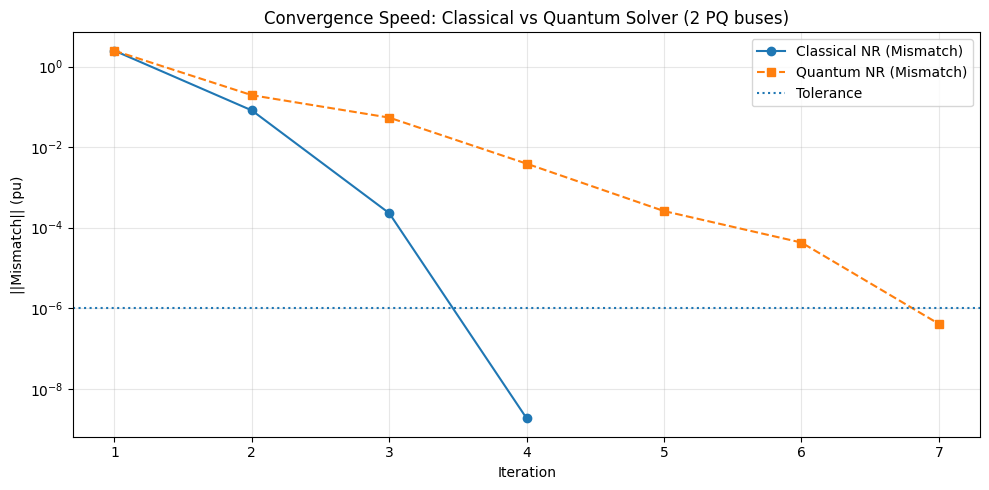


Last Jacobian Pauli Terms: 10
Quantum Advantage Scales Logarithmically with system size.


In [ ]:
# SECTION 7 — Results Comparison & Visualization (2 PQ buses)

print('\n' + '=' * 85)
print(f'{"Method":<16} {"V2 (pu)":<12} {"V3 (pu)":<12} {"d2 (°)":<12} {"d3 (°)":<12} {"Iters":<8} {"Time (ms)"}')
print('=' * 85)

print(f'{"Classical NR":<16} {V2c:<12.6f} {V3c:<12.6f} {d2c:<12.4f} {d3c:<12.4f} {it_c:<8} {t_c*1000:.1f}')
print(f'{"Quantum NR":<16} {V2q:<12.6f} {V3q:<12.6f} {d2q:<12.4f} {d3q:<12.4f} {it_q:<8} {t_q*1000:.1f}')

print('=' * 85)

print(f"\nSystem Configuration:")
print(f"  Bus 2 → P2={P2_sch} pu, Q2={Q2_sch} pu")
print(f"  Bus 3 → P3={P3_sch} pu, Q3={Q3_sch} pu")

# Convergence Plot

fig, ax = plt.subplots(figsize=(10, 5))

# Error is now index 5
ax.semilogy([h[0] for h in hist_c], [h[5] for h in hist_c], 'o-', label='Classical NR (Mismatch)')
ax.semilogy([h[0] for h in hist_q], [h[5] for h in hist_q], 's--', label='Quantum NR (Mismatch)')

ax.axhline(1e-6, linestyle=':', label='Tolerance')

ax.set_xlabel('Iteration')
ax.set_ylabel('||Mismatch|| (pu)')
ax.set_title('Convergence Speed: Classical vs Quantum Solver (2 PQ buses)')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
